Number of unique nodes in gaf_df: 574
Number of nodeIDs in kraken_calls_mges after filtering: 574


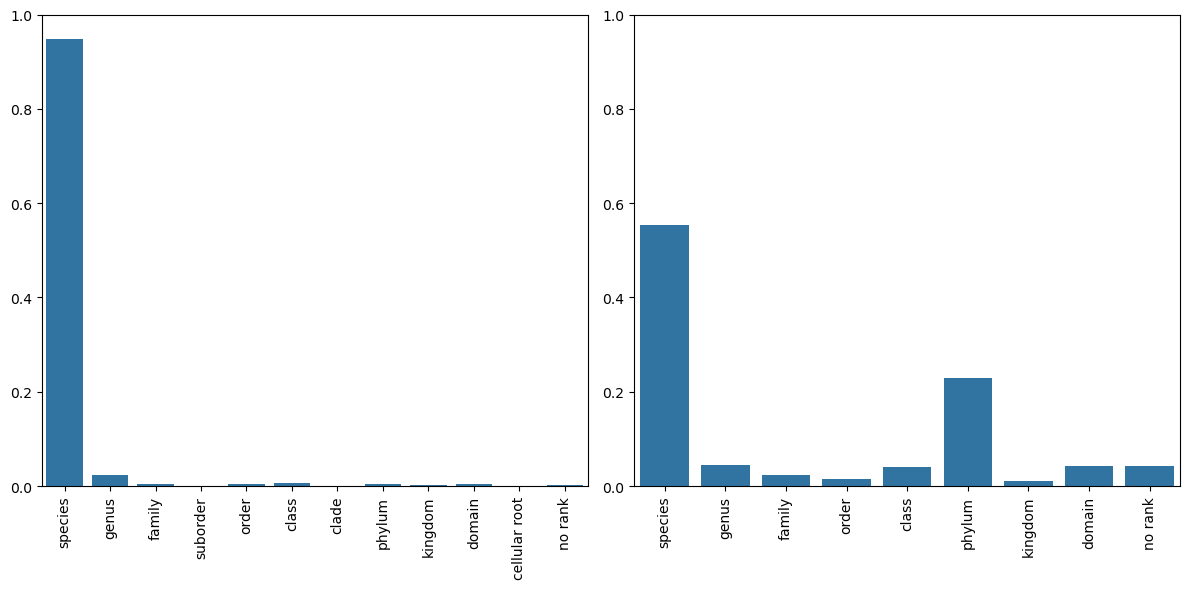

<Figure size 640x480 with 0 Axes>

In [ ]:
#!/usr/bin/env python3

import pandas as pd
from ete4 import NCBITaxa
from matplotlib import pyplot as plt
import seaborn as sns

# read in assembly_graph_after_simplification_kraken_out.txt
kraken_df = pd.read_csv("complete_ww_kraken_calls.txt", sep="\t", header=None, names=["classification_status","nodeID", "taxID"]) 

# read in complete_ww_v_all_mge.gaf
graphaligner_cols = [
        "query", "query_length", "query_start", "query_end", "strand", "path", 
        "path_length", "path_start", "path_end", "number_residue_matches", 
        "alignment_length", "mapping_quality", "snps_and_indels", 
        "alignment_score", "divergence", "perc_identity", "cigar"
    ]
gaf_df = pd.read_csv("complete_ww_v_all_mge.gaf", sep="\t", header=None, names=graphaligner_cols)

# remove "<" and ">" from path column in gaf_df, turn into list of nodeIDs
gaf_df["path"] = gaf_df["path"].str.replace("<", ",").str.replace(">", ",")
gaf_df["path"] = gaf_df["path"].str.split(",")
# remove empty strings from path lists
gaf_df["path"] = gaf_df["path"].apply(lambda x: [node for node in x if node != ""])

all_nodes = set()
for path in gaf_df["path"]:
    all_nodes.update(path)

print(f"Number of unique nodes in gaf_df: {len(all_nodes)}")

# create dictionary of nodeID to taxID from kraken_df
kraken_call = dict(zip(kraken_df["nodeID"], kraken_df["taxID"]))

# ensure all_nodes node ids and kraken_call node ids are the same type (string)
all_nodes = set(map(str, all_nodes))
kraken_call = {str(k): v for k, v in kraken_call.items()}

# chnge taxID 160674 to 570 
for nodeID, taxID in kraken_call.items():
    if taxID == 160674:
        kraken_call[nodeID] = 570
    if taxID == 0:
        kraken_call[nodeID] = 1

# filter kraken_call to only include nodeIDs that are in all_nodes
kraken_calls_mges = {k: v for k, v in kraken_call.items() if k in all_nodes}
print(f"Number of nodeIDs in kraken_calls_mges after filtering: {len(kraken_calls_mges)}")

ncbi = NCBITaxa()
# get taxonomic ranks for all taxIDs in kraken_call

#create dictionary to store nodeID, taxID, and rank
node_tax_rank = {}

for nodeID, taxID in kraken_calls_mges.items():
    rank = ncbi.get_rank([taxID])
    node_tax_rank[nodeID] = {"taxID": taxID, "rank": rank[taxID]}
# create dataframe from node_tax_rank dictionary
mge_node_tax_rank_df = pd.DataFrame.from_dict(node_tax_rank, orient="index").reset_index().rename(columns={"index": "nodeID"})


# create a dictionary to store nodeID, taxID, rank for all kraken calls
all_node_tax_rank = {}
for nodeID, taxID in kraken_call.items():
    rank = ncbi.get_rank([taxID])
    all_node_tax_rank[nodeID] = {"taxID": taxID, "rank": rank[taxID]}
# create dataframe from all_node_tax_rank dictionary
all_node_tax_rank_df = pd.DataFrame.from_dict(all_node_tax_rank, orient="index").reset_index().rename(columns={"index": "nodeID"})
# remove mge nodes from all_node_tax_rank_df
all_node_tax_rank_df = all_node_tax_rank_df[~all_node_tax_rank_df["nodeID"].isin(mge_node_tax_rank_df["nodeID"])]

# # save to csv
mge_node_tax_rank_df.to_csv("mge_node_tax_rank_df.csv", index=False)
all_node_tax_rank_df.to_csv("all_non_mge_node_tax_rank_df.csv", index=False)


# chnage ranks "strain", "subspecies" to "species" in both dataframes
mge_node_tax_rank_df["rank"] = mge_node_tax_rank_df["rank"].replace({"strain": "species", "subspecies": "species"})
all_node_tax_rank_df["rank"] = all_node_tax_rank_df["rank"].replace({"strain": "species", "subspecies": "species", "species group": "species", "forma specialis": "species", "serogroup": "species"})

# plot the proportion of each rank for mge_node_tax_rank_df and all_node_tax_rank_df
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
all_node_rank_counts = all_node_tax_rank_df["rank"].value_counts(normalize=True)
# order all_node_rank_counts : species, genus, family, suborder, order, class, clade, phylum, kingdom, domain, cellular root, no rank
rank_order = ["species", "genus", "family", "suborder", "order", "class", "clade", "phylum", "kingdom", "domain", "cellular root", "no rank"]
all_node_rank_counts = all_node_rank_counts.reindex(rank_order)
sns.barplot(x=all_node_rank_counts.index, y=all_node_rank_counts.values)
# y axis from 0 to 1
plt.ylim(0, 1)
plt.xticks(rotation=90)
# remove x axis label
plt.xlabel("")
plt.subplot(1, 2, 2)
mge_node_rank_counts = mge_node_tax_rank_df["rank"].value_counts(normalize=True)
# order mge_node_rank_counts : species, genus, family, order, class, phylum, kingdom, domain, no rank
rank_order = ["species", "genus", "family", "order", "class", "phylum", "kingdom", "domain", "no rank"]
mge_node_rank_counts = mge_node_rank_counts.reindex(rank_order)
sns.barplot(x=mge_node_rank_counts.index, y=mge_node_rank_counts.values)
# y axis from 0 to 1
plt.ylim(0, 1)
plt.xticks(rotation=90)
# remove x axis label
plt.xlabel("")
plt.tight_layout()
plt.show()
plt.savefig('../figures_tables/figure_S3.png', dpi=300)

Number of correct calls: 375
Number of incorrect calls: 199
Proportion of correct calls: 0.6533101045296167
Proportion of incorrect calls: 0.3466898954703833
      rank   correct
0  species  0.411950
1    genus  0.730769
2   family  0.923077
3    order  0.750000
4    class  0.956522
5   phylum  1.000000
6  kingdom  1.000000
7   domain  1.000000


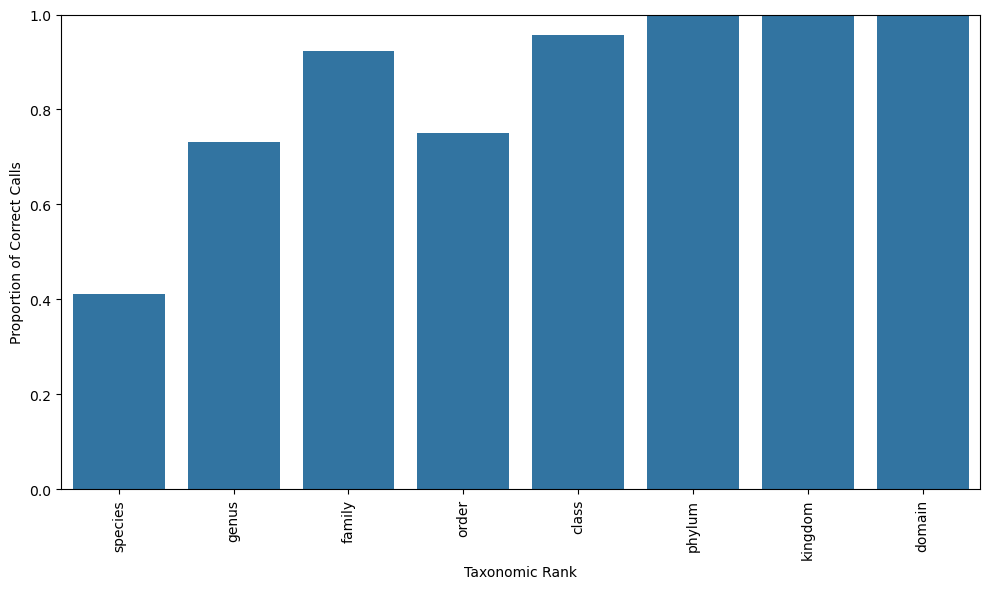

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
from ete4 import NCBITaxa
from matplotlib import pyplot as plt
import seaborn as sns

# compare taxID calls for nodes in gaf_df and kraken_df to ground truth 

# read in ground truth 
ground_truth_df = pd.read_csv("complete_ww_accns_taxid.tsv", sep="\t", header=None, names=["accn", "taxID"])
# read in nonMGEdf
nonMGEdf = pd.read_csv("all_non_mge_node_tax_rank_df.csv")
# read in MGEdf
MGEdf = pd.read_csv("mge_node_tax_rank_df.csv")
# read in all_mge_report.tsv
all_mge_report_df = pd.read_csv("all_mge_report.tsv", sep="\t")

# remove everything after the first space in the contig_id values in all_mge_report_df
all_mge_report_df["contig_id"] = all_mge_report_df["contig_id"].str.split(" ").str[0]

# read in complete_ww_v_all_mge.gaf
graphaligner_cols = [
        "query", "query_length", "query_start", "query_end", "strand", "path", 
        "path_length", "path_start", "path_end", "number_residue_matches", 
        "alignment_length", "mapping_quality", "snps_and_indels", 
        "alignment_score", "divergence", "perc_identity", "cigar"
    ]
gaf_df = pd.read_csv("complete_ww_v_all_mge.gaf", sep="\t", header=None, names=graphaligner_cols)

# create accn to nodeID df from all_mge_report_df and gaf_df
# create accn (sample_id) to contig_id df from all_mge_report_df
accn_to_contig_df = all_mge_report_df[["sample_id", "contig_id"]].drop_duplicates()

# keep only query and path columns from gaf_df
gaf_df = gaf_df[["query", "path"]]
# change query column name in gaf_df to contig_id
gaf_df = gaf_df.rename(columns={"query": "contig_id"})
# remove everything after the : in the contig_id values in gaf_df
gaf_df["contig_id"] = gaf_df["contig_id"].str.split(":").str[0]
# add accn column to gaf_df using accn_to_contig_df
gaf_df["accn"] = gaf_df["contig_id"].map(accn_to_contig_df.set_index("contig_id")["sample_id"])
# keep only first 15 characters from accn column in gaf_df
gaf_df["accn"] = gaf_df["accn"].str[:15]

# remove < and > from path column in gaf_df, turn into list of nodeIDs
gaf_df["path"] = gaf_df["path"].str.replace("<", ",").str.replace(">", ",")
gaf_df["path"] = gaf_df["path"].str.split(",")
# remove empty strings from path lists
gaf_df["path"] = gaf_df["path"].apply(lambda x: [node for node in x if node != ""])

# expand the gaf_df so that the path column is exploded into multiple rows, one for each nodeID in the path
gaf_df = gaf_df.explode("path").reset_index(drop=True)

# merge gaf_df with mge_node_tax_rank_df on nodeID to get taxID and rank for each node in the path
gaf_df = gaf_df.merge(mge_node_tax_rank_df, left_on="path", right_on="nodeID", how="left")

# remove contig_id and path columns from gaf_df
gaf_df = gaf_df.drop(columns=["contig_id", "path"])

# write gaf_df to csv
gaf_df.to_csv("gaf_df_with_taxID.csv", index=False)

# use ete get_lineage function, add lineage column to ground_truth_df
ncbi = NCBITaxa()
ground_truth_df["lineage"] = ground_truth_df["taxID"].apply(lambda x: ncbi.get_lineage(x))

# evaluate correct and incorrect calls for nonMGEdf and MGEdf
# correct call: If the gaf_df taxID is in the lineage of any matching accn in the ground truth taxID, then it is a correct call. 

# summarize gaf_df, group by nodeID and taxID, create a list of accns for each nodeID and taxID combination
gaf_summary_df = gaf_df.groupby(["nodeID", "taxID", "rank"])["accn"].apply(list).reset_index()

# create a corectness column in gaf_summary_df, initialize to False
gaf_summary_df["correct"] = False

# loop through gaf_summary_df rows
for index, row in gaf_summary_df.iterrows():
    nodeID = row["nodeID"]
    taxID = row["taxID"]
    accns = row["accn"]
    # for each accn in accns, check if taxID is in the lineage of the ground truth taxID for that accn
    for accn in accns:
        ground_truth_taxID = ground_truth_df[ground_truth_df["accn"] == accn]["taxID"].values
        if len(ground_truth_taxID) > 0:
            ground_truth_taxID = ground_truth_taxID[0]
            ground_truth_lineage = ground_truth_df[ground_truth_df["accn"] == accn]["lineage"].values[0]
            if taxID in ground_truth_lineage:
                gaf_summary_df.at[index, "correct"] = True
                break
# write gaf_summary_df to csv
gaf_summary_df.to_csv("gaf_summary_df.csv", index=False)

# print sum of true and false in correct column of gaf_summary_df
print(f"Number of correct calls: {gaf_summary_df['correct'].sum()}")
print(f"Number of incorrect calls: {len(gaf_summary_df) - gaf_summary_df['correct'].sum()}")

# print proportion of correct calls
print(f"Proportion of correct calls: {gaf_summary_df['correct'].mean()}")
print(f"Proportion of incorrect calls: {1 - gaf_summary_df['correct'].mean()}")

# plot the proportion of correct and incorrect calls for each rank, skip no rank
gaf_summary_df = gaf_summary_df[gaf_summary_df["rank"] != "no rank"]
# order ranks by species, genus, family, order, class, phylum, kingdom, domain
rank_order = ["species", "genus", "family", "order", "class", "phylum", "kingdom", "domain"]
gaf_summary_df["rank"] = pd.Categorical(gaf_summary_df["rank"], categories=rank_order, ordered=True)
gaf_summary_df = gaf_summary_df.sort_values("rank")

# calculate proportion of correct calls for each rank
gaf_summary_df = gaf_summary_df.groupby("rank")["correct"].mean().reset_index()
# print gaf_summary_df
print(gaf_summary_df)

plt.figure(figsize=(10, 6))
sns.barplot(x="rank", y="correct", data=gaf_summary_df)
plt.xticks(rotation=90)
plt.xlabel("Taxonomic Rank")
plt.ylabel("Proportion of Correct Calls")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
plt.savefig('../figures_tables/figure_S4.png', dpi=300)
    